# Periapical Lesion Detection — Experiment Suite
## Experiments Overview
| # | Experiment | Rationale |
|---|-----------|-----------|
| 1a | Single-class model — most frequent class | Reduce class confusion for dominant class |
| 1b | Single-class model — largest average box | Largest lesions may be easiest anchor |
| 2  | Two-class model — two most frequent classes | Intermediate complexity |
| 3  | Balanced dataset — equal samples per class | Remove frequency bias |

All experiments share the same base architecture (YOLOv10l) and hyper-parameters.  
Only the training data composition changes.


## 1. Environment Setup

In [1]:
!pip install ultralytics --quiet
!pip install Pillow matplotlib PyYAML --quiet

import os, shutil, random, time, math, yaml, collections
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('=' * 55)
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print('=' * 55)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.1 MB/s eta 0:00:00
PyTorch  : 2.11.0+cu128
CUDA     : True
GPU      : Tesla T4
VRAM     : 15.6 GB


## 2. Google Drive Mount & Path Configuration

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

WORK_DIR    = Path('/content/drive/MyDrive/Colab Notebooks')
DATASET_DIR = WORK_DIR / 'dataset'
yaml_path   = DATASET_DIR / 'data.yaml'
PROJECT     = str(WORK_DIR / 'runs_experiments')

CLASS_DISPLAY = ['Periapical_Type3', 'Periapical_Type4', 'Periapical_Type5']
NC = len(CLASS_DISPLAY)

# Verify original dataset
checks = {
    'data.yaml'   : yaml_path,
    'train images': DATASET_DIR / 'images' / 'train',
    'valid images': DATASET_DIR / 'images' / 'valid',
    'test images' : DATASET_DIR / 'images' / 'test',
    'train labels': DATASET_DIR / 'labels' / 'train',
    'valid labels': DATASET_DIR / 'labels' / 'valid',
    'test labels' : DATASET_DIR / 'labels' / 'test',
}
print('Dataset path check:')
all_ok = True
for name, p in checks.items():
    ok = p.exists()
    all_ok = all_ok and ok
    print(f'  {"OK" if ok else "MISSING":7} {name:<15} : {p}')

assert all_ok, 'Some paths are missing. Run Notebook 1 first!'
print('\nAll paths OK.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset path check:
  OK      data.yaml       : /content/drive/MyDrive/Colab Notebooks/dataset/data.yaml
  OK      train images    : /content/drive/MyDrive/Colab Notebooks/dataset/images/train
  OK      valid images    : /content/drive/MyDrive/Colab Notebooks/dataset/images/valid
  OK      test images     : /content/drive/MyDrive/Colab Notebooks/dataset/images/test
  OK      train labels    : /content/drive/MyDrive/Colab Notebooks/dataset/labels/train
  OK      valid labels    : /content/drive/MyDrive/Colab Notebooks/dataset/labels/valid
  OK      test labels     : /content/drive/MyDrive/Colab Notebooks/dataset/labels/test

All paths OK.


## 3. Label Analysis
Scan all label files (train + valid + test) to compute:
- Instance count per class
- Mean bounding-box area per class (in normalised units)


In [4]:
def parse_labels(label_dir: Path):
    """
    Returns a dict:
      {class_idx: {'count': int, 'areas': [float, ...]}}
    Area = w * h in normalised YOLO coordinates.
    """
    stats = {i: {'count': 0, 'areas': []} for i in range(NC)}
    for txt in label_dir.glob('*.txt'):
        for line in txt.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) != 5:
                continue
            cls_idx = int(parts[0])
            _, _, bw, bh = map(float, parts[1:])
            area = bw * bh
            stats[cls_idx]['count'] += 1
            stats[cls_idx]['areas'].append(area)
    return stats


# Aggregate across all splits
all_stats = {i: {'count': 0, 'areas': []} for i in range(NC)}
for split in ['train', 'valid', 'test']:
    s = parse_labels(DATASET_DIR / 'labels' / split)
    for cls_idx in range(NC):
        all_stats[cls_idx]['count'] += s[cls_idx]['count']
        all_stats[cls_idx]['areas'].extend(s[cls_idx]['areas'])

print(f'{"Class":<25} {"Count":>8} {"Mean Area (norm)":>18} {"Mean Area (%)":>14}')
print('-' * 68)
for i, name in enumerate(CLASS_DISPLAY):
    cnt  = all_stats[i]['count']
    areas = all_stats[i]['areas']
    mean_area = np.mean(areas) if areas else 0.0
    print(f'{name:<25} {cnt:>8} {mean_area:>18.6f} {mean_area*100:>13.3f}%')

# Derived decisions
counts     = {i: all_stats[i]['count'] for i in range(NC)}
mean_areas = {i: (np.mean(all_stats[i]['areas']) if all_stats[i]['areas'] else 0.0)
              for i in range(NC)}

sorted_by_count = sorted(counts,     key=counts.__getitem__,     reverse=True)
sorted_by_area  = sorted(mean_areas, key=mean_areas.__getitem__,  reverse=True)

most_frequent_cls  = sorted_by_count[0]
two_most_frequent  = sorted_by_count[:2]
largest_box_cls    = sorted_by_area[0]
min_count_all      = min(counts.values())

print(f'\nDecisions:')
print(f'  Exp 1a — most frequent class  : {CLASS_DISPLAY[most_frequent_cls]} (idx={most_frequent_cls}, n={counts[most_frequent_cls]})')
print(f'  Exp 1b — largest box class    : {CLASS_DISPLAY[largest_box_cls]} (idx={largest_box_cls}, area={mean_areas[largest_box_cls]*100:.3f}%)')
print(f'  Exp 2  — two most frequent    : {[CLASS_DISPLAY[c] for c in two_most_frequent]}')
print(f'  Exp 3  — balanced cap per cls : {min_count_all} samples')


Class                        Count   Mean Area (norm)  Mean Area (%)
--------------------------------------------------------------------
Periapical_Type3              4277           0.000964         0.096%
Periapical_Type4              1755           0.001951         0.195%
Periapical_Type5               709           0.005155         0.516%

Decisions:
  Exp 1a — most frequent class  : Periapical_Type3 (idx=0, n=4277)
  Exp 1b — largest box class    : Periapical_Type5 (idx=2, area=0.516%)
  Exp 2  — two most frequent    : ['Periapical_Type3', 'Periapical_Type4']
  Exp 3  — balanced cap per cls : 709 samples


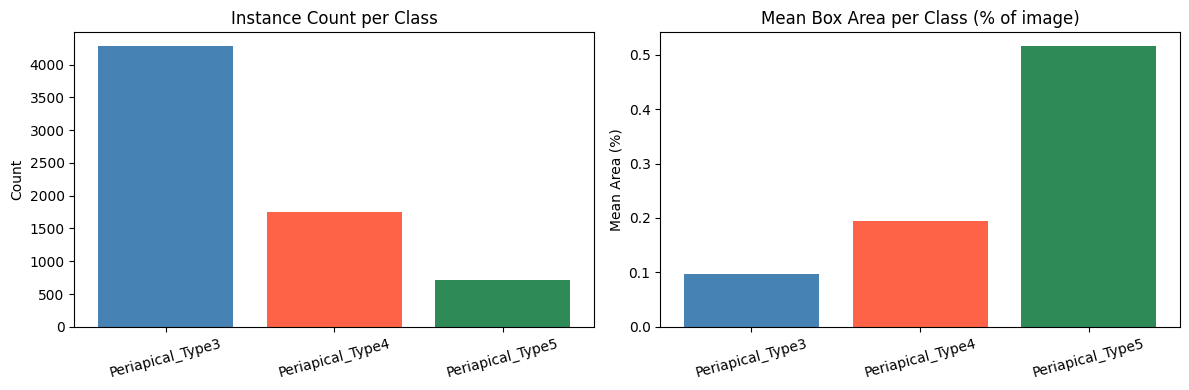

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count bar
axes[0].bar([CLASS_DISPLAY[i] for i in range(NC)],
            [counts[i] for i in range(NC)],
            color=['steelblue', 'tomato', 'seagreen'])
axes[0].set_title('Instance Count per Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

# Mean area bar
axes[1].bar([CLASS_DISPLAY[i] for i in range(NC)],
            [mean_areas[i] * 100 for i in range(NC)],
            color=['steelblue', 'tomato', 'seagreen'])
axes[1].set_title('Mean Box Area per Class (% of image)')
axes[1].set_ylabel('Mean Area (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


## 4. Dataset Builder Helpers
Functions that copy image/label subsets and write a custom `data.yaml`.


In [6]:
def build_filtered_dataset(
    dst_root      : Path,
    keep_classes  : list,
    max_per_class : int  = None,
    seed          : int  = SEED,
) -> Path:
    """
    Build a YOLO dataset that:
      - keeps only labels whose class is in keep_classes
      - re-indexes classes to 0..len(keep_classes)-1
      - optionally caps instances per class (balanced mode, train split only)
    Returns path to the new data.yaml.
    """
    rng = random.Random(seed)
    dst_root.mkdir(parents=True, exist_ok=True)

    cls_map   = {old: new for new, old in enumerate(keep_classes)}
    new_names = [CLASS_DISPLAY[c] for c in keep_classes]

    for split in ['train', 'valid', 'test']:
        img_dir = DATASET_DIR / 'images' / split
        lbl_dir = DATASET_DIR / 'labels' / split

        # Build list of (img_path, filtered_lines)
        samples = []
        for txt in sorted(lbl_dir.glob('*.txt')):
            kept_lines = []
            for line in txt.read_text().strip().splitlines():
                parts = line.split()
                if len(parts) != 5:
                    continue
                old_cls = int(parts[0])
                if old_cls not in cls_map:
                    continue
                new_cls = cls_map[old_cls]
                kept_lines.append(f'{new_cls} {parts[1]} {parts[2]} {parts[3]} {parts[4]}')
            if not kept_lines:
                continue

            img_path = None
            for ext in ['.jpg', '.jpeg', '.png']:
                p = img_dir / (txt.stem + ext)
                if p.exists():
                    img_path = p
                    break
            if img_path is None:
                continue
            samples.append((img_path, kept_lines))

        # Balancing / capping (train split only)
        if max_per_class is not None and split == 'train':
            cls_budget = {new: max_per_class for new in range(len(keep_classes))}
            rng.shuffle(samples)
            selected = []
            for img_path, lines in samples:
                line_classes = [int(l.split()[0]) for l in lines]
                if any(cls_budget.get(c, 0) > 0 for c in line_classes):
                    for c in set(line_classes):
                        if c in cls_budget:
                            cls_budget[c] = max(0, cls_budget[c] - line_classes.count(c))
                    selected.append((img_path, lines))
            samples = selected
            print(f'  [{split}] kept {len(samples)} images after balancing (cap={max_per_class}/class)')
        else:
            print(f'  [{split}] {len(samples)} images')

        dst_img = dst_root / 'images' / split
        dst_lbl = dst_root / 'labels' / split
        dst_img.mkdir(parents=True, exist_ok=True)
        dst_lbl.mkdir(parents=True, exist_ok=True)

        for img_path, lines in samples:
            shutil.copy2(img_path, dst_img / img_path.name)
            (dst_lbl / (img_path.stem + '.txt')).write_text('\n'.join(lines))

    yaml_content = {
        'path'  : str(dst_root),
        'train' : 'images/train',
        'val'   : 'images/valid',
        'test'  : 'images/test',
        'nc'    : len(keep_classes),
        'names' : new_names,
    }
    dst_yaml = dst_root / 'data.yaml'
    with open(dst_yaml, 'w') as f:
        yaml.dump(yaml_content, f, default_flow_style=False, sort_keys=False)

    print(f'  data.yaml -> {dst_yaml}')
    print(f'  Classes   : {new_names}')
    return dst_yaml


def count_split_images(ds_root: Path) -> dict:
    totals = {}
    for split in ['train', 'valid', 'test']:
        d = ds_root / 'images' / split
        totals[split] = len(list(d.glob('*.jpg'))) + len(list(d.glob('*.png'))) if d.exists() else 0
    return totals


## 5. Shared Training Helper
Single function that trains a YOLOv10l model given a `data.yaml` path.


In [7]:
from ultralytics import YOLO
import torch

MODEL_WEIGHTS = 'yolov10l.pt'

def train_experiment(
    exp_name : str,
    data_yaml: Path,
    epochs   : int   = 20,
    imgsz    : int   = 640,
    lr0      : float = 0.001,
) -> dict:
    """
    Train YOLOv10l and return a results summary dict.
    imgsz=640 is used for all experiments to stay within T4 VRAM (15 GB).
    """
    print(f'\n{"="*60}')
    print(f'  Training: {exp_name}')
    print(f'  data    : {data_yaml}')
    print(f'{"="*60}')

    # Free any leftover VRAM before starting
    torch.cuda.empty_cache()

    model = YOLO(MODEL_WEIGHTS)
    t0 = time.time()

    results = model.train(
        data          = str(data_yaml),
        epochs        = epochs,
        imgsz         = imgsz,
        batch         = 16,          # safe for imgsz=640 on T4
        optimizer     = 'AdamW',
        lr0           = lr0,
        lrf           = 0.01,
        cos_lr        = True,
        weight_decay  = 0.0005,
        warmup_epochs = 3,
        mosaic        = 0.5,
        fliplr        = 0.5,
        degrees       = 5,
        hsv_h         = 0.01,
        hsv_s         = 0.3,
        hsv_v         = 0.4,
        patience      = 20,
        seed          = SEED,
        exist_ok      = True,
        project       = PROJECT,
        name          = exp_name,
        plots         = True,
        cache         = False,       # set True if dataset fits in RAM
        workers       = 2,           # Colab Drive is slow; 2 workers avoids stalls
        verbose       = False,
    )

    elapsed = time.time() - t0
    best_pt  = Path(PROJECT) / exp_name / 'weights' / 'best.pt'

    # Free VRAM before validation
    del model
    torch.cuda.empty_cache()

    # Evaluate on test split
    best_model = YOLO(str(best_pt))
    test_m = best_model.val(
        data     = str(data_yaml),
        split    = 'test',
        imgsz    = imgsz,
        batch    = 16,
        device   = 0,
        plots    = True,
        project  = PROJECT,
        name     = exp_name + '_test',
        exist_ok = True,
        verbose  = False,
    )

    del best_model
    torch.cuda.empty_cache()

    summary = {
        'exp_name' : exp_name,
        'best_pt'  : best_pt,
        'elapsed_h': elapsed / 3600,
        'mAP50'    : test_m.box.map50,
        'mAP50_95' : test_m.box.map,
        'precision': test_m.box.mp,
        'recall'   : test_m.box.mr,
    }

    print(f'\n  [{exp_name}] Test results:')
    print(f'    mAP50     : {summary["mAP50"]:.4f}')
    print(f'    mAP50-95  : {summary["mAP50_95"]:.4f}')
    print(f'    Precision : {summary["precision"]:.4f}')
    print(f'    Recall    : {summary["recall"]:.4f}')
    print(f'    Time      : {elapsed/3600:.2f} h')

    return summary

all_summaries = []


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 6. Experiment 1a — Single Class: Most Frequent
Train a binary detector on only the most frequent class.


In [8]:
EXP1A_ROOT = WORK_DIR / 'datasets' / 'exp1a_most_frequent'
EXP1A_YAML = build_filtered_dataset(
    dst_root      = EXP1A_ROOT,
    keep_classes  = [most_frequent_cls],
    max_per_class = None,
)
split_info = count_split_images(EXP1A_ROOT)
print(f'  Split sizes: {split_info}')


  [train] 1971 images
  [valid] 400 images
  [test] 426 images
  data.yaml -> /content/drive/MyDrive/Colab Notebooks/datasets/exp1a_most_frequent/data.yaml
  Classes   : ['Periapical_Type3']
  Split sizes: {'train': 1971, 'valid': 400, 'test': 426}


In [9]:
import torch
torch.cuda.empty_cache()
print("VRAM freed before exp1a")

VRAM freed before exp1a


In [10]:
summary_1a = train_experiment(
    exp_name  = 'exp1a_most_frequent',
    data_yaml = EXP1A_YAML,
)
all_summaries.append(summary_1a)



  Training: exp1a_most_frequent
  data    : /content/drive/MyDrive/Colab Notebooks/datasets/exp1a_most_frequent/data.yaml
Ultralytics 8.4.55 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/datasets/exp1a_most_frequent/data.yaml, degrees=5, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.3, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mod

## 7. Experiment 1b — Single Class: Largest Average Box
Train a binary detector on only the class with the largest mean bounding box.


In [11]:
EXP1B_ROOT = WORK_DIR / 'datasets' / 'exp1b_largest_box'
EXP1B_YAML = build_filtered_dataset(
    dst_root      = EXP1B_ROOT,
    keep_classes  = [largest_box_cls],
    max_per_class = None,
)
split_info = count_split_images(EXP1B_ROOT)
print(f'  Split sizes: {split_info}')


  [train] 435 images
  [valid] 113 images
  [test] 107 images
  data.yaml -> /content/drive/MyDrive/Colab Notebooks/datasets/exp1b_largest_box/data.yaml
  Classes   : ['Periapical_Type5']
  Split sizes: {'train': 435, 'valid': 113, 'test': 107}


In [12]:
import torch
torch.cuda.empty_cache()
print("VRAM freed before exp1b")

VRAM freed before exp1b


In [13]:
summary_1b = train_experiment(
    exp_name  = 'exp1b_largest_box',
    data_yaml = EXP1B_YAML,
)
all_summaries.append(summary_1b)



  Training: exp1b_largest_box
  data    : /content/drive/MyDrive/Colab Notebooks/datasets/exp1b_largest_box/data.yaml
Ultralytics 8.4.55 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/datasets/exp1b_largest_box/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.3, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov1

## 8. Experiment 2 — Two Most Frequent Classes
Train on the two most frequent classes to reduce the harder third class.


In [14]:
EXP2_ROOT = WORK_DIR / 'datasets' / 'exp2_two_frequent'
EXP2_YAML = build_filtered_dataset(
    dst_root      = EXP2_ROOT,
    keep_classes  = two_most_frequent,
    max_per_class = None,
)
split_info = count_split_images(EXP2_ROOT)
print(f'  Split sizes: {split_info}')


  [train] 2511 images
  [valid] 516 images
  [test] 533 images
  data.yaml -> /content/drive/MyDrive/Colab Notebooks/datasets/exp2_two_frequent/data.yaml
  Classes   : ['Periapical_Type3', 'Periapical_Type4']
  Split sizes: {'train': 2511, 'valid': 516, 'test': 533}


In [15]:
import torch
torch.cuda.empty_cache()
print("VRAM freed before exp2")

VRAM freed before exp2


In [16]:
summary_2 = train_experiment(
    exp_name  = 'exp2_two_frequent',
    data_yaml = EXP2_YAML,
)
all_summaries.append(summary_2)



  Training: exp2_two_frequent
  data    : /content/drive/MyDrive/Colab Notebooks/datasets/exp2_two_frequent/data.yaml
Ultralytics 8.4.55 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/datasets/exp2_two_frequent/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.3, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov1

## 9. Experiment 3 — Balanced Dataset (All 3 Classes)
Cap each class to the count of the rarest class to remove frequency bias.


In [17]:
# Recompute min_count from train split only (balancing only applies to training)
train_stats = parse_labels(DATASET_DIR / 'labels' / 'train')
train_counts = {i: train_stats[i]['count'] for i in range(NC)}
min_train_count = min(train_counts.values())

print('Train-split instance counts:')
for i, name in enumerate(CLASS_DISPLAY):
    print(f'  {name:<25}: {train_counts[i]}')
print(f'\nCap per class (train only): {min_train_count}')

EXP3_ROOT = WORK_DIR / 'datasets' / 'exp3_balanced'
EXP3_YAML = build_filtered_dataset(
    dst_root      = EXP3_ROOT,
    keep_classes  = list(range(NC)),
    max_per_class = min_train_count,
)
split_info = count_split_images(EXP3_ROOT)
print(f'  Split sizes: {split_info}')


Train-split instance counts:
  Periapical_Type3         : 3017
  Periapical_Type4         : 1229
  Periapical_Type5         : 473

Cap per class (train only): 473
  [train] kept 1005 images after balancing (cap=473/class)
  [valid] 588 images
  [test] 590 images
  data.yaml -> /content/drive/MyDrive/Colab Notebooks/datasets/exp3_balanced/data.yaml
  Classes   : ['Periapical_Type3', 'Periapical_Type4', 'Periapical_Type5']
  Split sizes: {'train': 1005, 'valid': 588, 'test': 590}


In [18]:
import torch
torch.cuda.empty_cache()
print("VRAM freed before exp3")

VRAM freed before exp3


In [19]:
summary_3 = train_experiment(
    exp_name  = 'exp3_balanced',
    data_yaml = EXP3_YAML,
)
all_summaries.append(summary_3)



  Training: exp3_balanced
  data    : /content/drive/MyDrive/Colab Notebooks/datasets/exp3_balanced/data.yaml
Ultralytics 8.4.55 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/datasets/exp3_balanced/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.3, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10l.pt, momen

## 10. Results Comparison


In [20]:
print(f'\n{"Experiment":<30} {"mAP50":>8} {"mAP50-95":>10} {"Precision":>11} {"Recall":>8} {"Time(h)":>8}')
print('-' * 78)
for s in all_summaries:
    print(f'{s["exp_name"]:<30} {s["mAP50"]:>8.4f} {s["mAP50_95"]:>10.4f} '
          f'{s["precision"]:>11.4f} {s["recall"]:>8.4f} {s["elapsed_h"]:>8.2f}')



Experiment                        mAP50   mAP50-95   Precision   Recall  Time(h)
------------------------------------------------------------------------------
exp1a_most_frequent              0.5111     0.2159      0.5138   0.5412     0.76
exp1b_largest_box                0.5574     0.2575      0.5624   0.5804     0.23
exp2_two_frequent                0.4960     0.2355      0.5151   0.4854     0.96
exp3_balanced                    0.3795     0.1748      0.4406   0.4415     0.46


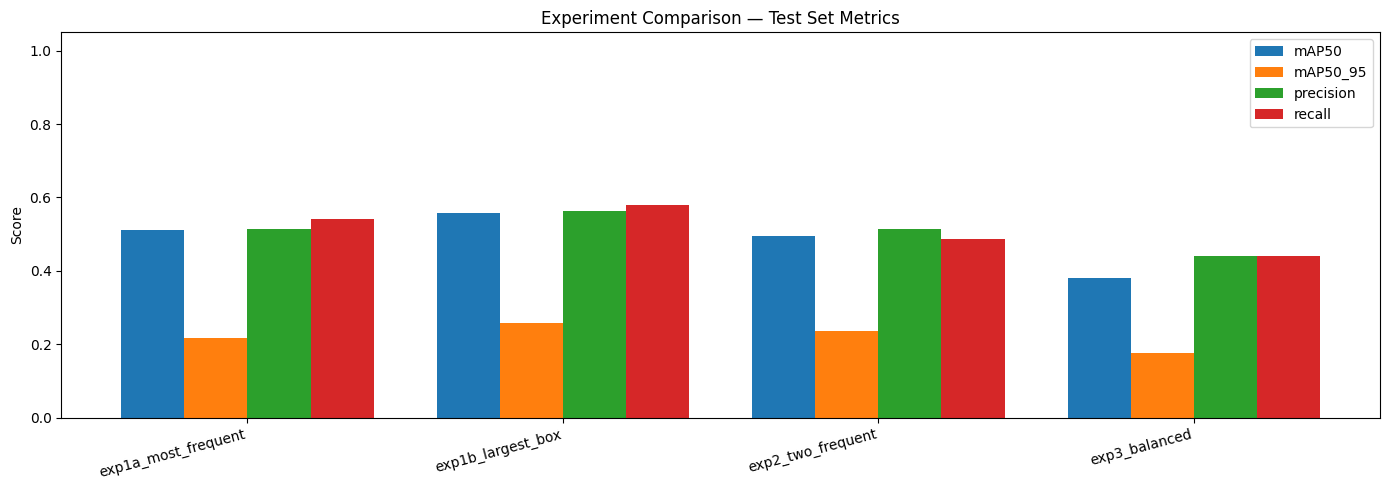

In [21]:
metrics  = ['mAP50', 'mAP50_95', 'precision', 'recall']
labels   = [s['exp_name'] for s in all_summaries]
x        = np.arange(len(labels))
bar_w    = 0.2

fig, ax = plt.subplots(figsize=(14, 5))
for i, metric in enumerate(metrics):
    vals = [s[metric] for s in all_summaries]
    ax.bar(x + i * bar_w, vals, bar_w, label=metric)

ax.set_xticks(x + bar_w * (len(metrics) - 1) / 2)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Experiment Comparison — Test Set Metrics')
ax.legend()
plt.tight_layout()
plt.show()


## 11. Export Best Weights to Google Drive


In [22]:
export_dir = WORK_DIR / 'exports_experiments'
export_dir.mkdir(parents=True, exist_ok=True)

for s in all_summaries:
    pt = s['best_pt']
    if pt.exists():
        dst = export_dir / f'{s["exp_name"]}_best.pt'
        shutil.copy2(pt, dst)
        print(f'  Copied {pt.name} -> {dst}')
    else:
        print(f'  WARNING: {pt} not found')

print('\nAll weights exported to:', export_dir)


  Copied best.pt -> /content/drive/MyDrive/Colab Notebooks/exports_experiments/exp1a_most_frequent_best.pt
  Copied best.pt -> /content/drive/MyDrive/Colab Notebooks/exports_experiments/exp1b_largest_box_best.pt
  Copied best.pt -> /content/drive/MyDrive/Colab Notebooks/exports_experiments/exp2_two_frequent_best.pt
  Copied best.pt -> /content/drive/MyDrive/Colab Notebooks/exports_experiments/exp3_balanced_best.pt

All weights exported to: /content/drive/MyDrive/Colab Notebooks/exports_experiments


## 12. Summary

| Experiment | Classes | Strategy | Key metric |
|-----------|---------|----------|-----------|
| exp1a | 1 (most frequent) | Single-class — reduce confusion | mAP50 |
| exp1b | 1 (largest box)   | Single-class — easiest anchors  | mAP50 |
| exp2  | 2 (top-2 freq)    | Drop hardest class              | mAP50 |
| exp3  | 3 (all, balanced) | Equal samples — remove bias     | mAP50 |

Weights saved under `WORK_DIR/exports_experiments/`.
